# Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings                                                                      
warnings.filterwarnings('ignore')  
from IPython.display import Audio, display, Markdown

# Loading Data

## TESS Data

In [2]:
tess_path = '../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data'

In [3]:
tess_file_paths = []
tess_labels = []

for folder in os.listdir(tess_path):
    folder_path = os.path.join(tess_path, folder)
    label = folder[4:] 
    label = label.lower() 

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        tess_file_paths.append(file_path)
        tess_labels.append(label)

In [4]:
tess_data = pd.DataFrame({
    'paths' : tess_file_paths,
    'emotions' : tess_labels
})

## SAVEE Data

In [5]:
savee_path = "../Data/SAVEE data/SAVEE data"

In [6]:
savee_file_paths = []
savee_labels = []

for folder in os.listdir(savee_path):
    folder_path = os.path.join(savee_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            filename = file.split('.')[0]
            label = ''.join(filter(str.isalpha, filename)).lower()
            file_path = os.path.join(folder_path, file)
            savee_file_paths.append(file_path)
            savee_labels.append(label)

In [7]:
savee_data = pd.DataFrame({
    'paths': savee_file_paths,
    'emotions': savee_labels
})

In [8]:
emotion_mapping = {
    'a': 'angry',
    'd': 'disgust',
    'h': 'happy',
    'sa': 'sad',
    'su': 'pleasant_surprise',
    'f': 'fearful',
    'n': 'neutral'
}

savee_data['emotions'] = savee_data['emotions'].map(emotion_mapping)

In [9]:
emotion_data = pd.concat([
    tess_data.assign(dataset='TESS'),
    savee_data.assign(dataset='SAVEE')
], ignore_index=True)

# Analysis

##  Display top 5 rows

In [10]:
emotion_data.head()

,paths,emotions,dataset
0,../Data/TESS Toronto emotional speech set data...,angry,TESS
1,../Data/TESS Toronto emotional speech set data...,angry,TESS
2,../Data/TESS Toronto emotional speech set data...,angry,TESS
3,../Data/TESS Toronto emotional speech set data...,angry,TESS
4,../Data/TESS Toronto emotional speech set data...,angry,TESS


##  Display bottom 5 rows

In [11]:
emotion_data.tail()

,paths,emotions,dataset
3275,../Data/SAVEE data/SAVEE data\KL\su11.wav,pleasant_surprise,SAVEE
3276,../Data/SAVEE data/SAVEE data\KL\su12.wav,pleasant_surprise,SAVEE
3277,../Data/SAVEE data/SAVEE data\KL\su13.wav,pleasant_surprise,SAVEE
3278,../Data/SAVEE data/SAVEE data\KL\su14.wav,pleasant_surprise,SAVEE
3279,../Data/SAVEE data/SAVEE data\KL\su15.wav,pleasant_surprise,SAVEE


##  Display Shape of the dataset

In [12]:
print(f"Shape of the dataset: {emotion_data.shape}")

Shape of the dataset: (3280, 3)


##  Display information of the data

In [13]:
emotion_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3280 entries, 0 to 3279
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   paths     3280 non-null   object
 1   emotions  3280 non-null   object
 2   dataset   3280 non-null   object
dtypes: object(3)
memory usage: 77.0+ KB


##  Displaying Column Names

In [14]:
emotion_data.columns

Index(['paths', 'emotions', 'dataset'], dtype='object')

##  Displaying Features data types

In [15]:
emotion_data.dtypes

paths       object
emotions    object
dataset     object
dtype: object

##  Displaying type of Dataset

In [16]:
type(emotion_data)

pandas.core.frame.DataFrame

##  Checking duplicates

In [17]:
print("Any Duplicates in the Dataset:",emotion_data.duplicated().any())
print("Number of Duplicates in the Dataset:",emotion_data.duplicated().sum())

Any Duplicates in the Dataset: False
Number of Duplicates in the Dataset: 0


##  Categorical Data Analysis

In [18]:
emotion_counts = emotion_data['emotions'].value_counts().reset_index()
emotion_counts.columns = ['Emotion', 'Count']

display(emotion_counts)

,Emotion,Count
0,neutral,520
1,angry,460
2,disgust,460
3,happy,460
4,sad,460
5,fear,400
6,pleasant_surprise,260
7,pleasant_surprised,200
8,fearful,60


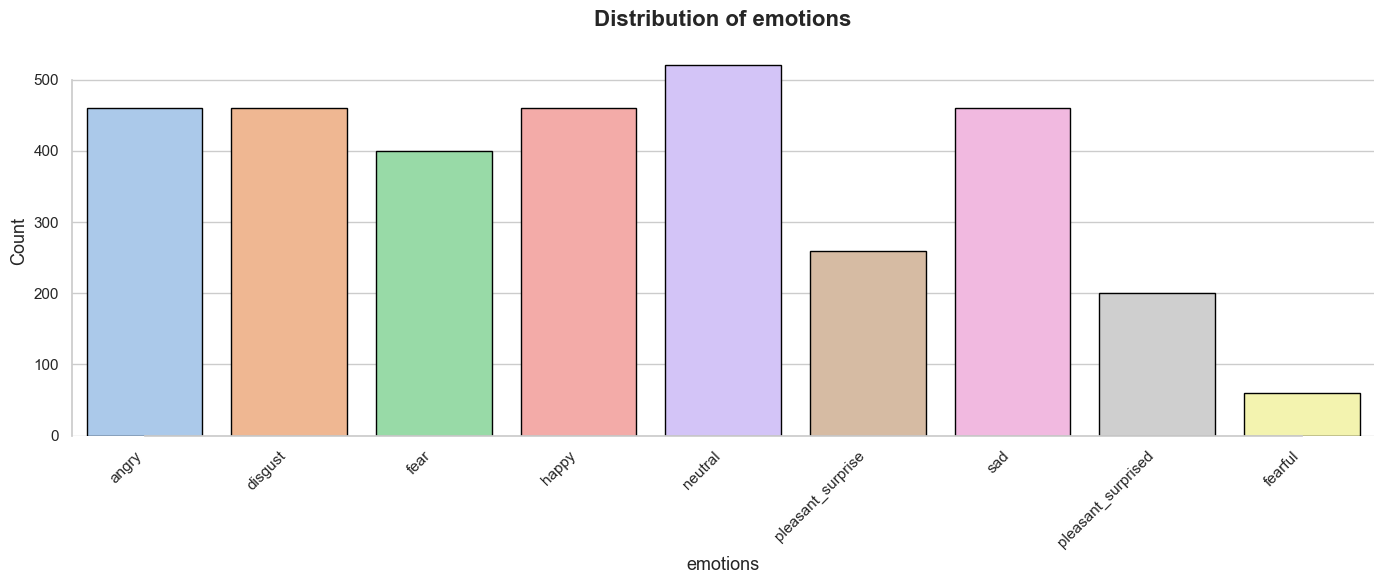

In [19]:
emotion_data_cat = emotion_data[['emotions']]

sns.set(style="whitegrid")
plt.rcParams.update({'axes.titlesize': 16, 'axes.titleweight': 'bold', 'axes.labelsize': 12})

num_features = len(emotion_data_cat.columns)

for i, col in enumerate(emotion_data_cat.columns, 1):
    plt.figure(figsize=(14, 6))
    
    palette = sns.color_palette("pastel", emotion_data_cat[col].nunique())
    
    ax = sns.countplot(x=col, data=emotion_data_cat, palette=palette, edgecolor='black')
    
    plt.title(f'Distribution of {col}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(col, fontsize=13)
    plt.ylabel('Count', fontsize=13)
    
    if emotion_data_cat[col].nunique() > 5:
        plt.xticks(rotation=45, ha='right', fontsize=11)
    else:
        plt.xticks(fontsize=11)
    
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

In [20]:
unique_emotions = emotion_data['emotions'].unique()

for emotion in unique_emotions:
    emotion_files = emotion_data[emotion_data['emotions'] == emotion]['paths'].tolist()
    
    if len(emotion_files) < 2:
        continue  
    
    sample_file = emotion_files[1]
    
    display(Markdown(f"#### Emotion: {emotion.capitalize()}"))
    
    display(Audio(sample_file, autoplay=True))

#### Emotion: Angry

#### Emotion: Disgust

#### Emotion: Fear

#### Emotion: Happy

#### Emotion: Neutral

#### Emotion: Pleasant_surprise

#### Emotion: Sad

#### Emotion: Pleasant_surprised

#### Emotion: Fearful